In [1]:
import numpy as np
import pandas as pd

from pathlib import Path
from catboost import CatBoostClassifier

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc,
    confusion_matrix
)

import matplotlib.pyplot as plt

RANDOM_STATE = 42
WEIGHT_STRENGTH = 0.95
ITERATIONS = 300
LEARNING_RATE = 0.05
DEPTH = 7
L2_LEAF_REG = 5


In [2]:
PROJECT_DIR = Path(r"C:\Users\Parsian\Desktop\superstore-project\New folder")

DATA_DIR = (
    PROJECT_DIR
    / "Phase 1 - Data preparation & warehouse"
    / "data"
    / "csv"
)

fact_sales = pd.read_csv(DATA_DIR / "FactSales.csv")
dim_customer = pd.read_csv(DATA_DIR / "DimCustomer.csv")
dim_geography = pd.read_csv(DATA_DIR / "DimGeography.csv")
dim_product = pd.read_csv(DATA_DIR / "DimProduct.csv")
dim_date = pd.read_csv(DATA_DIR / "DimDate.csv")
dim_priority = pd.read_csv(DATA_DIR / "DimOrderPriority.csv")

print("FactSales:", fact_sales.shape)
print("DimCustomer:", dim_customer.shape)
print("DimGeography:", dim_geography.shape)
print("DimProduct:", dim_product.shape)
print("DimDate:", dim_date.shape)
print("DimOrderPriority:", dim_priority.shape)

FactSales: (49670, 16)
DimCustomer: (1589, 4)
DimGeography: (3772, 7)
DimProduct: (10246, 5)
DimDate: (1468, 33)
DimOrderPriority: (4, 2)


In [3]:
df = (
    fact_sales
    .merge(dim_customer, on="CustomerKey", how="left")
    .merge(dim_geography, on="GeographyKey", how="left")
    .merge(dim_product, on="ProductKey", how="left")
    .merge(
        dim_date,
        left_on="OrderDateKey",
        right_on="DateKey",
        how="left"
    )
    .merge(dim_priority, on="PriorityKey", how="left")
)

print("Final dataset shape:", df.shape)
df.head()

Final dataset shape: (49670, 63)


,SalesRowKey,OrderID,ProductKey,CustomerKey,GeographyKey,ShipModeKey,PriorityKey,OrderDateKey,ShipDateKey,Sales,...,PersianDayOfWeekName,PersianWeekOfYearName,PersianWeekOfYearNo,PersianFullName,SeasonCode,SeasonName,IsGregorianLeap,IsPersianLeap,PersianYearMonthSort,Order Priority
0,2363,MX-2011-117107,2750,731,2640,4,4,20111015,20111019,703.16,...,شنبه,هفته 31,31,شنبه 23 مهر 1390,3,پاییز,0,0,139007,Medium
1,831,MX-2014-135272,3021,1383,2605,4,4,20141106,20141110,32.12,...,پنج شنبه,هفته 34,34,پنج شنبه 15 آبان 1393,3,پاییز,0,0,139308,Medium
2,1511,MX-2012-147886,404,278,2605,4,4,20120411,20120415,163.44,...,چهارشنبه,هفته 4,4,چهارشنبه 23 فروردین 1391,1,بهار,0,0,139101,Medium
3,3399,MX-2014-107265,6837,151,2551,4,4,20140624,20140628,35.24,...,سه شنبه,هفته 15,15,سه شنبه 3 تیر 1393,2,تابستان,0,0,139304,Medium
4,850,MX-2012-131254,4681,699,2551,4,4,20121204,20121208,64.88,...,سه شنبه,هفته 38,38,سه شنبه 14 آذر 1391,3,پاییز,0,0,139109,Medium


In [4]:
df["GregorianDate"] = pd.to_datetime(df["GregorianDate"])

df["OrderMonth"] = df["GregorianDate"].dt.month

df["OrderDayOfWeek"] = df["GregorianDate"].dt.dayofweek

df["OrderSeason"] = df["SeasonCode"]

df["IsMonthBoundary"] = (
    df["GregorianDate"].dt.is_month_end |
    (df["GregorianDate"].dt.day == 1)
).astype(int)

df[
    [
        "GregorianDate",
        "OrderMonth",
        "OrderDayOfWeek",
        "OrderSeason",
        "IsMonthBoundary"
    ]
].head()

,GregorianDate,OrderMonth,OrderDayOfWeek,OrderSeason,IsMonthBoundary
0,2011-10-15,10,5,3,0
1,2014-11-06,11,3,3,0
2,2012-04-11,4,2,1,0
3,2014-06-24,6,1,2,0
4,2012-12-04,12,1,3,0


In [5]:
# ORDER-LEVEL DATASET
# Aggregate sales lines to one row per OrderID BEFORE train/validation split.

shipmode_per_order = df.groupby("OrderID")["ShipModeKey"].nunique()
inconsistent_orders = shipmode_per_order[shipmode_per_order > 1]

print("Unique orders:", df["OrderID"].nunique())
print("Orders with multiple ShipModeKey values:", len(inconsistent_orders))

if len(inconsistent_orders) > 0:
    raise ValueError(
        "Some OrderID values have more than one ShipModeKey. "
        "Resolve these records before training."
    )

order_agg = {
    "Quantity": "sum",
    "Sales": "sum",
    "Discount": "sum",
    "Profit": "sum",
    "ShippingCost": "sum",
    "Segment": "first",
    "Region": "first",
    "Market": "first",
    "Sub-Category": "first",
    "Order Priority": "first",
    "OrderMonth": "first",
    "OrderDayOfWeek": "first",
    "OrderSeason": "first",
    "IsMonthBoundary": "first",
    "CustomerKey": "first",
    "GeographyKey": "first",
    "OrderDateKey": "first",
    "ShipModeKey": "first"
}

order_df = df.groupby("OrderID", as_index=False).agg(order_agg)

order_df = order_df.merge(
    df.groupby("OrderID").size().rename("OrderLineCount"),
    left_on="OrderID",
    right_index=True,
    how="left"
)

# FEATURE ENGINEERING
# These ratio features are designed to give the model more information
# about the relative shipping burden and order economics.
order_df["ShippingCostPerSales"] = (
    order_df["ShippingCost"] / order_df["Sales"].replace(0, np.nan)
).fillna(0)

order_df["ShippingCostPerItem"] = (
    order_df["ShippingCost"] / order_df["Quantity"].replace(0, np.nan)
).fillna(0)

order_df["SalesPerItem"] = (
    order_df["Sales"] / order_df["Quantity"].replace(0, np.nan)
).fillna(0)

order_df["ProfitMargin"] = (
    order_df["Profit"] / order_df["Sales"].replace(0, np.nan)
).fillna(0)

order_df["DiscountAmount"] = (
    order_df["Sales"] * order_df["Discount"]
)

print("Engineered features added:")
print([
    "ShippingCostPerSales",
    "ShippingCostPerItem",
    "SalesPerItem",
    "ProfitMargin",
    "DiscountAmount"
])


# Check dimensions that should be constant within an order.
for col in [
    "CustomerKey", "GeographyKey", "OrderDateKey",
    "Segment", "Region", "Market", "Order Priority",
    "OrderMonth", "OrderDayOfWeek", "OrderSeason"
]:
    bad = df.groupby("OrderID")[col].nunique(dropna=False)
    print(f"{col} - inconsistent orders: {(bad > 1).sum()}")

print("Order-level dataset shape:", order_df.shape)
print("Order-level target distribution:")
print(order_df["ShipModeKey"].value_counts().sort_index())

base_features = [
    "Quantity",
    "Sales",
    "Discount",
    "Profit",
    "ShippingCost",
    "OrderLineCount",
    "Segment",
    "Region",
    "Market",
    "Sub-Category",
    "Order Priority",
    "OrderMonth",
    "OrderDayOfWeek",
    "OrderSeason",
    "IsMonthBoundary",
    "ShippingCostPerSales",
    "ShippingCostPerItem",
    "SalesPerItem",
    "ProfitMargin",
    "DiscountAmount"
]

categorical_cols = [
    "Segment",
    "Region",
    "Market",
    "Sub-Category",
    "Order Priority",
    "OrderMonth",
    "OrderDayOfWeek",
    "OrderSeason"
]

X = order_df[base_features].copy()
y = order_df["ShipModeKey"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts().sort_index())

order_df.head()


Unique orders: 25033
Orders with multiple ShipModeKey values: 0
Engineered features added:
['ShippingCostPerSales', 'ShippingCostPerItem', 'SalesPerItem', 'ProfitMargin', 'DiscountAmount']
CustomerKey - inconsistent orders: 0
GeographyKey - inconsistent orders: 0
OrderDateKey - inconsistent orders: 0
Segment - inconsistent orders: 0
Region - inconsistent orders: 0
Market - inconsistent orders: 0
Order Priority - inconsistent orders: 0
OrderMonth - inconsistent orders: 0
OrderDayOfWeek - inconsistent orders: 0
OrderSeason - inconsistent orders: 0
Order-level dataset shape: (25033, 25)
Order-level target distribution:
ShipModeKey
1     3718
2     1311
3     4993
4    15011
Name: count, dtype: int64
X shape: (25033, 20)
y shape: (25033,)

Target distribution:
ShipModeKey
1     3718
2     1311
3     4993
4    15011
Name: count, dtype: int64


,OrderID,Quantity,Sales,Discount,Profit,ShippingCost,Segment,Region,Market,Sub-Category,...,CustomerKey,GeographyKey,OrderDateKey,ShipModeKey,OrderLineCount,ShippingCostPerSales,ShippingCostPerItem,SalesPerItem,ProfitMargin,DiscountAmount
0,AE-2011-9160,8,161.082,1.4,-246.078,9.56,Consumer,EMEA,EMEA,Machines,...,1211,1486,20111003,4,2,0.059349,1.195000,20.135250,-1.527657,225.514796
1,AE-2013-1130,7,228.996,1.4,-236.964,60.18,Consumer,EMEA,EMEA,Fasteners,...,509,1487,20131014,2,2,0.262799,8.597143,32.713714,-1.034795,320.594395
2,AE-2013-1530,3,23.634,1.4,-38.076,3.16,Corporate,EMEA,EMEA,Storage,...,1100,1487,20131231,3,2,0.133706,1.053333,7.878000,-1.611069,33.087599
3,AE-2014-2840,1,42.480,0.7,-75.060,8.04,Consumer,EMEA,EMEA,Storage,...,1186,1486,20141105,1,1,0.189266,8.040000,42.480000,-1.766949,29.735999
4,AE-2014-3830,16,281.502,4.2,-429.108,19.38,Consumer,EMEA,EMEA,Art,...,606,1487,20141213,4,6,0.068845,1.211250,17.593875,-1.524352,1182.308380


In [6]:
# Split after aggregation: no OrderID can occur in both train and validation.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Orders in training:", len(X_train))
print("Orders in validation:", len(X_val))
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)


Orders in training: 20026
Orders in validation: 5007
y_train: (20026,)
y_val: (5007,)


In [7]:
class_counts = y_train.value_counts().sort_index()

n_samples = len(y_train)
n_classes = y_train.nunique()

class_weights_list = [
    (n_samples / (n_classes * count)) ** WEIGHT_STRENGTH
    for count in class_counts.values
]

print("Class counts:")
print(class_counts)

print("\nClass weights:")
print(class_weights_list)

Class counts:
ShipModeKey
1     2974
2     1049
3     3994
4    12009
Name: count, dtype: int64

Class weights:
[np.float64(1.6401500952158785), np.float64(4.413882783281649), np.float64(1.239423858639509), np.float64(0.43553795426042285)]


In [8]:
features_to_remove = [
    [],
    [
        "IsMonthBoundary",
        "Quantity",
        "Discount",
        "Profit",
        "OrderLineCount",
        "Sub-Category"
    ]
]

feature_sets = {
    f"Remove {', '.join(rem) if rem else ''}":
        [f for f in base_features if f not in rem]
    for rem in features_to_remove
}

for exp_name, features in feature_sets.items():
    print(exp_name)
    print("Number of features:", len(features))
    print(features)
    print()


Remove 
Number of features: 20
['Quantity', 'Sales', 'Discount', 'Profit', 'ShippingCost', 'OrderLineCount', 'Segment', 'Region', 'Market', 'Sub-Category', 'Order Priority', 'OrderMonth', 'OrderDayOfWeek', 'OrderSeason', 'IsMonthBoundary', 'ShippingCostPerSales', 'ShippingCostPerItem', 'SalesPerItem', 'ProfitMargin', 'DiscountAmount']

Remove IsMonthBoundary, Quantity, Discount, Profit, OrderLineCount, Sub-Category
Number of features: 14
['Sales', 'ShippingCost', 'Segment', 'Region', 'Market', 'Order Priority', 'OrderMonth', 'OrderDayOfWeek', 'OrderSeason', 'ShippingCostPerSales', 'ShippingCostPerItem', 'SalesPerItem', 'ProfitMargin', 'DiscountAmount']



In [9]:
results = []

best_model = None
best_features = None
best_score = -1

for exp_name, features in feature_sets.items():

    Xtr = X_train[features].copy()
    Xv = X_val[features].copy()

    cat_cols = [
        c for c in categorical_cols
        if c in features
    ]

    for c in cat_cols:
        Xtr[c] = Xtr[c].astype(str)
        Xv[c] = Xv[c].astype(str)

    cat_indices = [
        Xtr.columns.get_loc(c)
        for c in cat_cols
    ]

    model = CatBoostClassifier(
        loss_function="MultiClass",
        iterations=ITERATIONS,
        learning_rate=LEARNING_RATE,
        depth=DEPTH,
        l2_leaf_reg=L2_LEAF_REG,
        random_seed=RANDOM_STATE,
        class_weights=class_weights_list,
        eval_metric="TotalF1",
        od_type="Iter",
        od_wait=40,
        verbose=False,
        allow_writing_files=False
    )

    model.fit(
        Xtr,
        y_train,
        cat_features=cat_indices,
        eval_set=(Xv, y_val),
        use_best_model=True
    )

    y_pred = model.predict(Xv).flatten().astype(int)

    acc = accuracy_score(y_val, y_pred)

    macro = f1_score(
        y_val,
        y_pred,
        average="macro"
    )

    weighted = f1_score(
        y_val,
        y_pred,
        average="weighted"
    )

    results.append(
        (
            exp_name,
            acc,
            macro,
            weighted,
            model.get_best_iteration()
        )
    )

    if macro > best_score:
        best_score = macro
        best_model = model
        best_features = features

print("Experiments completed.")

Experiments completed.


In [10]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Experiment",
        "Accuracy",
        "Macro_F1",
        "Weighted_F1",
        "Best_Iter"
    ]
)

results_df

,Experiment,Accuracy,Macro_F1,Weighted_F1,Best_Iter
0,Remove,0.587378,0.444102,0.609563,49
1,"Remove IsMonthBoundary, Quantity, Discount, Pr...",0.573397,0.431840,0.597297,9


In [11]:
best_row = results_df.loc[
    results_df["Macro_F1"].idxmax()
]

print("Best Experiment:", best_row["Experiment"])
print("Accuracy:", best_row["Accuracy"])
print("Macro F1:", best_row["Macro_F1"])
print("Weighted F1:", best_row["Weighted_F1"])
print("Best Iteration:", best_row["Best_Iter"])

print("\nBest Features:")
print(best_features)

Xv_report = X_val[best_features].copy()
for c in categorical_cols:
    if c in best_features:
        Xv_report[c] = Xv_report[c].astype(str)

y_pred_report = best_model.predict(Xv_report).flatten().astype(int)

print("\nClassification Report:")
print(classification_report(y_val, y_pred_report, digits=4))


Best Experiment: Remove 
Accuracy: 0.5873776712602357
Macro F1: 0.44410204400622444
Weighted F1: 0.6095625274620305
Best Iteration: 49

Best Features:
['Quantity', 'Sales', 'Discount', 'Profit', 'ShippingCost', 'OrderLineCount', 'Segment', 'Region', 'Market', 'Sub-Category', 'Order Priority', 'OrderMonth', 'OrderDayOfWeek', 'OrderSeason', 'IsMonthBoundary', 'ShippingCostPerSales', 'ShippingCostPerItem', 'SalesPerItem', 'ProfitMargin', 'DiscountAmount']



Classification Report:
              precision    recall  f1-score   support

           1     0.5179    0.4476    0.4802       744
           2     0.1624    0.2634    0.2009       262
           3     0.2805    0.3794    0.3226       999
           4     0.8346    0.7195    0.7728      3002

    accuracy                         0.5874      5007
   macro avg     0.4488    0.4525    0.4441      5007
weighted avg     0.6418    0.5874    0.6096      5007



In [12]:
Xv_best = X_val[best_features].copy()

cat_cols_best = [
    c for c in categorical_cols
    if c in best_features
]

for c in cat_cols_best:
    Xv_best[c] = Xv_best[c].astype(str)

y_pred_best = (
    best_model
    .predict(Xv_best)
    .flatten()
    .astype(int)
)

y_proba = best_model.predict_proba(Xv_best)

classes = best_model.classes_

print("Classes:", classes)
print("Predictions:", len(y_pred_best))
print("Probabilities shape:", y_proba.shape)

Classes: [1 2 3 4]
Predictions: 5007
Probabilities shape: (5007, 4)


In [13]:
final_df = order_df.loc[X_val.index].copy()

final_df["Actual_ShipModeKey"] = y_val.to_numpy()
final_df["Predicted_ShipModeKey"] = y_pred_best

for i, cls in enumerate(classes):
    final_df[f"Probability_Class_{cls}"] = y_proba[:, i]

final_df["Prediction_Correct"] = (
    final_df["Actual_ShipModeKey"]
    == final_df["Predicted_ShipModeKey"]
)

final_df.head()


,OrderID,Quantity,Sales,Discount,Profit,ShippingCost,Segment,Region,Market,Sub-Category,...,SalesPerItem,ProfitMargin,DiscountAmount,Actual_ShipModeKey,Predicted_ShipModeKey,Probability_Class_1,Probability_Class_2,Probability_Class_3,Probability_Class_4,Prediction_Correct
20673,NI-2013-4410,5,91.6920,1.40,-89.8380,3.92,Corporate,Africa,Africa,Binders,...,18.338400,-0.979780,128.368798,4,4,0.106566,0.099049,0.242256,0.552129,True
10148,ID-2014-19225,10,1468.5264,0.54,-119.7936,107.45,Consumer,Southeast Asia,APAC,Paper,...,146.852640,-0.081574,793.004255,4,4,0.106733,0.101239,0.232359,0.559669,True
4333,CA-2014-152275,6,6.6720,0.20,0.5004,0.35,Corporate,Central,US,Art,...,1.112000,0.075000,1.334400,4,4,0.105153,0.095547,0.234224,0.565075,True
22161,TU-2013-3770,7,266.5080,1.80,-275.1120,17.86,Consumer,EMEA,EMEA,Binders,...,38.072571,-1.032284,479.714419,4,4,0.105233,0.100491,0.243293,0.550983,True
6199,ES-2012-3075765,2,246.0240,0.10,65.6040,38.18,Corporate,North,EU,Phones,...,123.012000,0.266657,24.602400,1,1,0.418319,0.324005,0.190350,0.067326,True


In [14]:
output_csv = PROJECT_DIR / "ShipMode_OrderLevel_Predictions.csv"

final_df.to_csv(
    output_csv,
    index=False
)

print(f"{len(final_df)} order-level predictions saved:")
print(output_csv)


5007 order-level predictions saved:
C:\Users\Parsian\Desktop\superstore-project\New folder\ShipMode_OrderLevel_Predictions.csv


In [15]:
y_val_bin = np.column_stack(
    [(y_val.to_numpy() == cls).astype(int) for cls in classes]
)

roc_auc_macro = roc_auc_score(
    y_val_bin,
    y_proba,
    multi_class="ovr",
    average="macro"
)

roc_auc_weighted = roc_auc_score(
    y_val_bin,
    y_proba,
    multi_class="ovr",
    average="weighted"
)

print(f"ROC-AUC macro: {roc_auc_macro:.4f}")
print(f"ROC-AUC weighted: {roc_auc_weighted:.4f}")

cm = confusion_matrix(y_val, y_pred_best, labels=classes)

print("\nConfusion Matrix:")
print(pd.DataFrame(
    cm,
    index=[f"Actual_{c}" for c in classes],
    columns=[f"Predicted_{c}" for c in classes]
))


ROC-AUC macro: 0.7783
ROC-AUC weighted: 0.7927

Confusion Matrix:
          Predicted_1  Predicted_2  Predicted_3  Predicted_4
Actual_1          333          141          184           86
Actual_2          101           69           72           20
Actual_3          141          157          379          322
Actual_4           68           58          716         2160


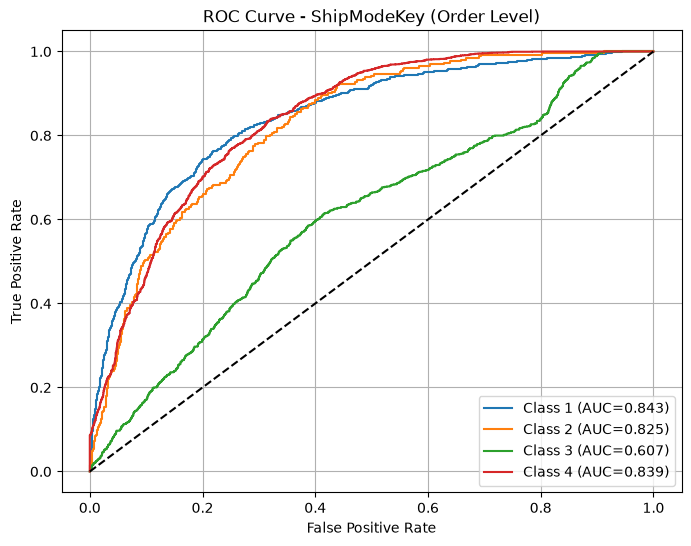

In [16]:
plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(
        y_val_bin[:, i],
        y_proba[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"Class {cls} (AUC={auc(fpr, tpr):.3f})"
    )

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ShipModeKey (Order Level)")
plt.legend()
plt.grid(True)
plt.show()


### Methodological note

This version predicts `ShipModeKey` at the order level. All line items for an `OrderID` are aggregated before the train/validation split, so the same order cannot leak into both sets. `ShipDateKey` is not used because it is known after shipping. `ShippingCost` should remain only if it is available when the customer selects the shipping option; otherwise remove it from `base_features`.
